In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def wrangle(filepath):
    #read csv into DataFrame
    df = pd.read_csv(filepath)

    # =====================================================
    
    # Merge Patient Admission Date and Patient Admission Time column
    df["Admission DateTime"] = pd.to_datetime(
        df["Patient Admission Date"] + " " + df["Patient Admission Time"], dayfirst=True
    )

    # Drop columns with more than 40% null values, merged, and irrelvant 
    df.drop(columns=(["Department Referral",
                      "Patient Satisfaction Score", 
                      "Patient Admission Date",
                      "Patient Admission Time", 
                      "Patient Id", 
                      "Merged"]),
            inplace=True)

    # =====================================================
    
    # Set Admission DateTime column as index
    df.set_index("Admission DateTime", inplace=True)

    # Sort index
    df.sort_index(inplace=True)

    # Create column with day name
    df.insert(0, "Admission Day", df.index.day_name() )

    # Create Ordered Days in Visualization
    day_order = [
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ]

    df["Admission Day"] = pd.Categorical(
        df["Admission Day"],
        categories = day_order,
        ordered = True
    )


     # Create column with month name
    df.insert(0, "Admission Month", df.index.month_name() )

    # Create Ordered Days in Visualization
    month_order = [
        "January",
        "February",
        "March",
        "April",
        "May",
        "June",
        "July",
        "August",
        "September",
        "October",
        "November",
        "December"
    ]

    df["Admission Month"] = pd.Categorical(
        df["Admission Month"],
        categories = month_order,
        ordered = True
    )

    # Extract hour from datetime index
    df.insert(0, "Time Group", df.index.hour )

    bins = [0, 6, 9, 12, 15, 18, 21, 24]

    labels = [
        "00:00–05:59",
        "06:00–08:59",
        "09:00–11:59",
        "12:00–14:59",
        "15:00–17:59",
        "18:00–20:59",
        "21:00–23:59"
    ]
    
    df["Time Group"] = pd.cut(
        df["Time Group"],
        bins=bins,
        labels=labels,
        right=False,
        include_lowest=True
    )

    # make it chronological
    df["Time Group"] = pd.Categorical(
    df["Time Group"],
    categories=labels,
    ordered=True
    )
    # =====================================================
    
    # Create Age Groups
    bins = [0, 5, 10, 15, 20, 30, 40, 50, 60, 70, 80]

    labels = [
        "Under Five",
        "School Age Child",
        "Early Adolescent",
        "Late Adolescent",
        "Young Adult",
        "Early Adult",
        "Midlife Adult",
        "Late Adult",
        "Young Elderly",
        "Older Elderly"
    ]

    df["Age Group"] = pd.cut(
        df["Patient Age"],
        bins=bins,
        labels=labels,
        right=False
    )

    # Make Age Group Chronological
    df["Age Group"] = pd.Categorical(
        df["Age Group"],
        categories=labels,
        ordered=True
    )

    # Higher-level category mapping
    age_category_map = {
        "Under Five": "Child",
        "School Age Child": "Child",

        "Early Adolescent": "Adolescent",
        "Late Adolescent": "Adolescent",

        "Young Adult": "Adult",
        "Early Adult": "Adult",
        "Midlife Adult": "Adult",
        "Late Adult": "Adult",

        "Young Elderly": "Elderly",
        "Older Elderly": "Elderly"
    }

    df["Age Category"] = df["Age Group"].map(age_category_map)

    # Make the Age Category ordered
    category_order = [
        "Child",
        "Adolescent",
        "Adult",
        "Elderly"
    ]
    
    df["Age Category"] = pd.Categorical(
        df["Age Category"],
        categories=category_order,
        ordered=True
    )

    # Color Mapping
    age_color_map = {
        "Child": "yellow",
        "Adolescent": "red",
        "Adult": "blue",
        "Elderly": "gray"
    }
    
    df["Age Color"] = df["Age Category"].map(age_color_map)

    return df

def coefficient_of_variation(series):
    return(series.std()/series.mean()) * 100

In [3]:
df = wrangle (r"C:\Users\HP\Downloads\archive\healthcare_analytics_patient_flow_data.csv")
df.head()

,Time Group,Admission Month,Admission Day,Patient Gender,Patient Age,Patient Race,Patient Admission Flag,Patient Waittime,Age Group,Age Category,Age Color
Admission DateTime,,,,,,,,,,,
2023-04-01 01:13:00,00:00–05:59,April,Saturday,Male,60,Two or More Races,Admission,35,Young Elderly,Elderly,gray
2023-04-01 01:21:00,00:00–05:59,April,Saturday,Male,18,Two or More Races,Admission,40,Late Adolescent,Adolescent,red
2023-04-01 02:45:00,00:00–05:59,April,Saturday,Male,62,Asian,Not Admission,12,Young Elderly,Elderly,gray
2023-04-01 04:34:00,00:00–05:59,April,Saturday,Male,79,White,Not Admission,21,Older Elderly,Elderly,gray
2023-04-01 06:07:00,06:00–08:59,April,Saturday,Female,6,White,Admission,52,School Age Child,Child,yellow


In [4]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 9216 entries, 2023-04-01 01:13:00 to 2024-10-30 23:44:00
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   Time Group              9216 non-null   category
 1   Admission Month         9216 non-null   category
 2   Admission Day           9216 non-null   category
 3   Patient Gender          9216 non-null   str     
 4   Patient Age             9216 non-null   int64   
 5   Patient Race            9216 non-null   str     
 6   Patient Admission Flag  9216 non-null   str     
 7   Patient Waittime        9216 non-null   int64   
 8   Age Group               9216 non-null   category
 9   Age Category            9216 non-null   category
 10  Age Color               9216 non-null   category
dtypes: category(6), int64(2), str(3)
memory usage: 487.6 KB


In [5]:
df.describe().round(0)

,Patient Age,Patient Waittime
count,9216.0,9216.0
mean,40.0,35.0
std,23.0,15.0
min,1.0,10.0
25%,20.0,23.0
50%,39.0,35.0
75%,60.0,48.0
max,79.0,60.0


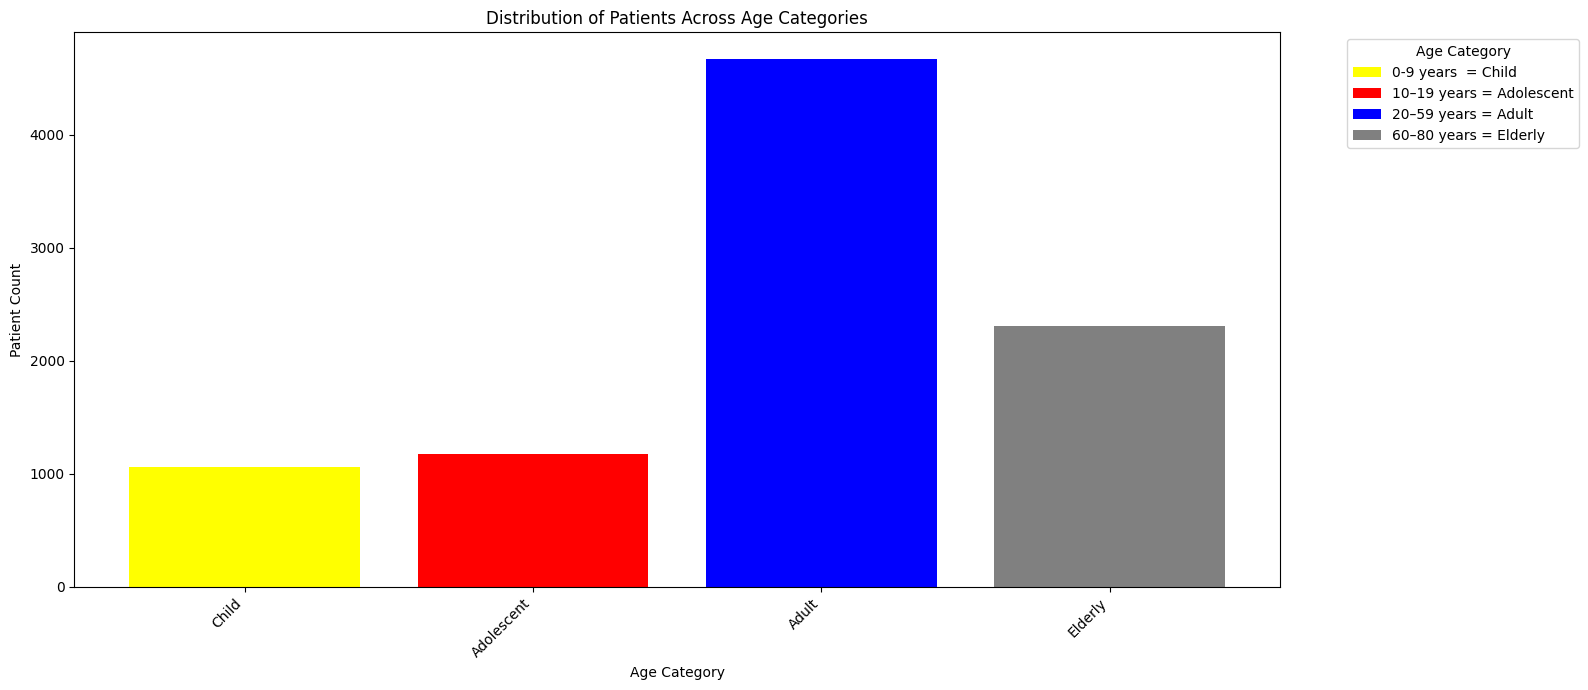

In [6]:
# AGE CATEGORY DISTRIBUTION ANALYSIS

age_cat_counts = df["Age Category"].value_counts().sort_index()

colors = (
    df.drop_duplicates("Age Category")
      .set_index("Age Category")["Age Color"]
      .reindex(age_cat_counts.index)
)

fig, ax = plt.subplots(figsize=(13,7))


bars = ax.bar(
    age_cat_counts.index,
    age_cat_counts.values,
    color=colors
)

plt.title("Distribution of Patients Across Age Categories")
plt.xlabel("Age Category")
plt.ylabel("Patient Count")

plt.xticks(rotation=45, ha='right')

plt.tight_layout()

# Create legend 
legend_labels = [
    "0-9 years  = Child",
    "10–19 years = Adolescent",
    "20–59 years = Adult",
    "60–80 years = Elderly",
]

ax.legend(bars, legend_labels, title="Age Category", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

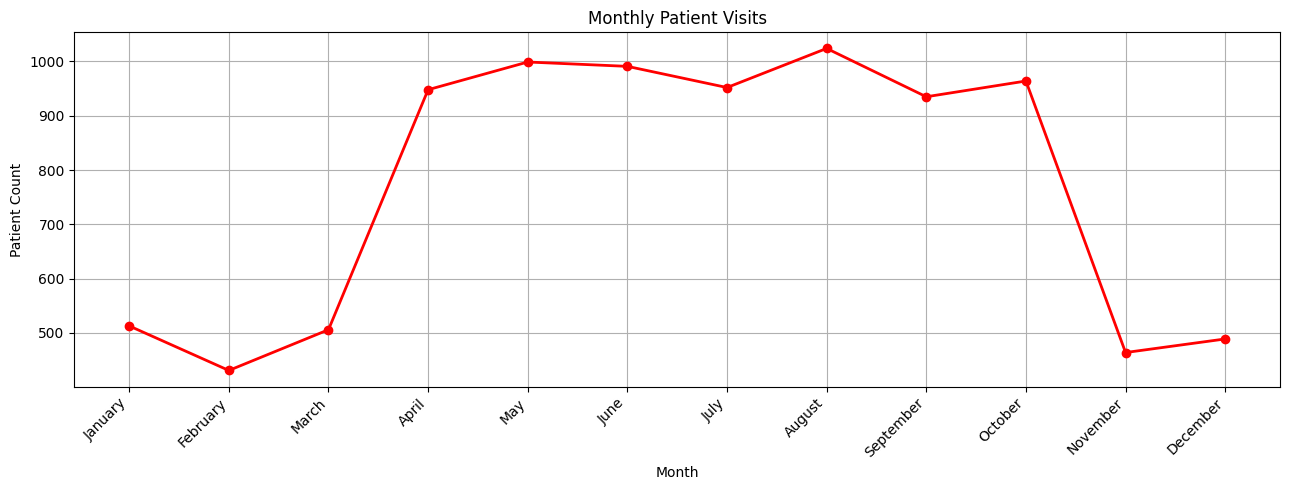

In [7]:
# MONTHLY PATIENT VISITS ANALYSIS

month_visits = df["Admission Month"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(13,5))

ax.plot(
    month_visits.index,
    month_visits.values,
    marker='o',
    linewidth=2,
    color="red"
)

plt.title("Monthly Patient Visits")
plt.xlabel("Month")
plt.ylabel("Patient Count")

plt.grid(True)

plt.xticks(rotation=45, ha="right")

plt.tight_layout();


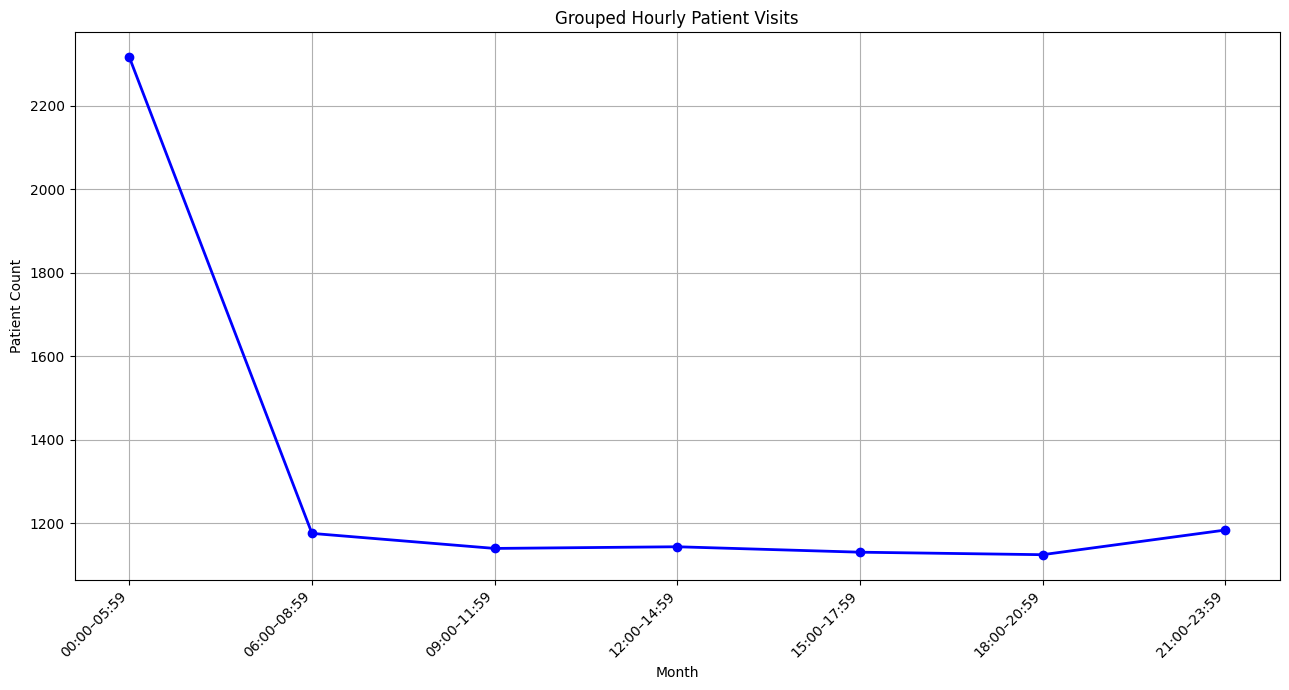

In [8]:
# GROUPED HOURLY PATIENT VISITS ANALYSIS

hourly_visits = df["Time Group"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(13,7))

ax.plot(
    hourly_visits.index,
    hourly_visits.values,
    marker='o',
    linewidth=2,
    color="blue"
)

plt.title("Grouped Hourly Patient Visits")
plt.xlabel("Month")
plt.ylabel("Patient Count")

plt.grid(True)

plt.xticks(rotation=45, ha="right")

plt.tight_layout();


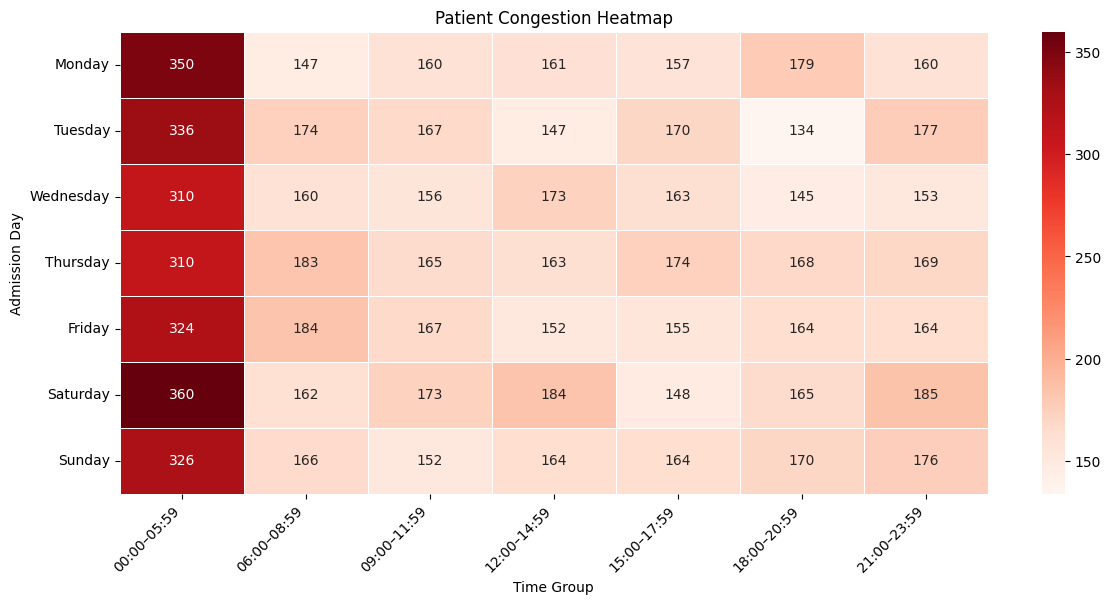

In [9]:
# PATIENT CONGESTION ANALYSIS

heatmap_data = df.pivot_table(
    index="Admission Day",
    columns="Time Group",
    values="Patient Age",
    aggfunc="count",
    observed=False
)

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="Reds",
    linewidths=0.5
)

plt.title("Patient Congestion Heatmap")
plt.xlabel("Time Group")
plt.ylabel("Admission Day")

plt.xticks(rotation=45, ha="right")

plt.show()

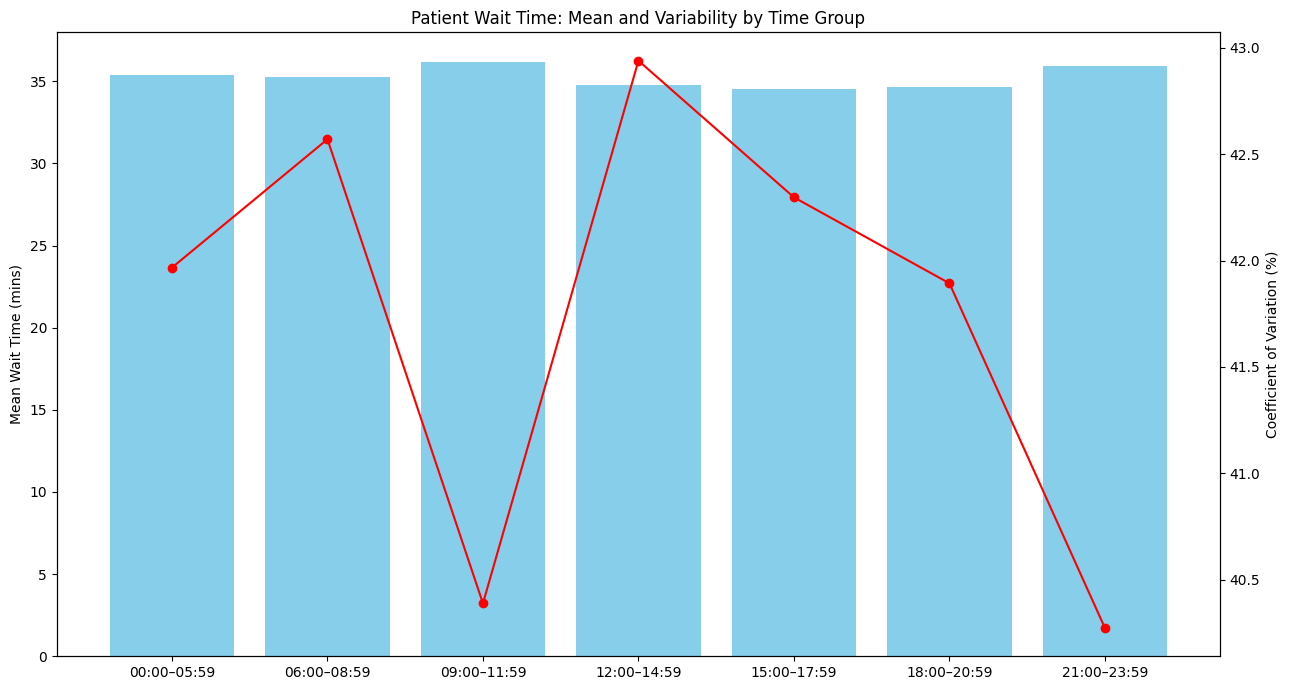

In [10]:
# PATIENT WAIT TIME VARIABILITY ANALYSIS

summary = df.groupby("Time Group", observed=False)["Patient Waittime"].agg(
    Mean_Wait="mean",
    CV=coefficient_of_variation
)

fig, ax1 = plt.subplots(figsize=(13,7))

# Bar plot for mean wait
ax1.bar(
    summary.index,
    summary["Mean_Wait"],
    color="skyblue"
)

ax1.set_ylabel("Mean Wait Time (mins)")

# Second axis for CV
ax2 = ax1.twinx()

ax2.plot(
    summary.index,
    summary["CV"],
    marker="o",
    color="red",
    )

ax2.set_ylabel("Coefficient of Variation (%)")

plt.title("Patient Wait Time: Mean and Variability by Time Group")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()